## Topographical downscaling of HRRR DSWRF

Global horizontal radiation splitting into direct and diffuse components. \
Application of various topographic models.

In [1]:
import numpy as np
from datetime import datetime, timedelta
import math as m

from netCDF4 import Dataset

from snobedo.input import HrrrParameter, SmrfTopo
from snobedo.shortwave import TopoShade
from snobedo.input import SmrfTopo

import matplotlib.pyplot as plt

from topocalc.horizon import horizon

In [2]:
# helper functions
# import dswrf_func as swo

## Declare variables to find data 

In [3]:
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR_2022/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

## Access the sky-view factors from topo

In [4]:
with Dataset(ERW_TOPO_FILE) as dem:
    sky_view_factor = dem['sky_view_factor'][:].astype(np.float64)
    dem = dem['dem'][:].astype(np.float64)

In [5]:
sky_view_factor

masked_array(
  data=[[0.90764373, 0.90160327, 0.87204783, ..., 0.96763542, 0.97887733,
         0.98330146],
        [0.87995018, 0.86740591, 0.81930077, ..., 0.97601105, 0.98206188,
         0.98354592],
        [0.83752437, 0.8177492 , 0.77636379, ..., 0.97050725, 0.97584268,
         0.97335441],
        ...,
        [0.87855814, 0.89022444, 0.8855338 , ..., 0.95064361, 0.95388958,
         0.93882772],
        [0.90449759, 0.86569677, 0.84933238, ..., 0.95202325, 0.94747276,
         0.92465977],
        [0.890127  , 0.82381173, 0.78123565, ..., 0.9661788 , 0.94509181,
         0.91614504]],
  mask=False,
  fill_value=1e+20)

## Calculate shade for given date range

This uses the center X and Y of the topo and the mean elevation to calculate the sun position.

### Create a object that can calculate shade based on a topo file 

Here the underlying library for the sun position:  
https://github.com/skyfielders/python-skyfield/

In [6]:
topo_shade = TopoShade(
    ERW_TOPO_FILE, TopoShade.SolarMethods.SKYFIELD
)

### Create a 24 hour time range 

In [7]:
time_range = np.arange(
        '2022-03-01',
        '2022-03-02',
        np.timedelta64(1, 'h'),
        dtype='datetime64[s]'
    )

In [8]:
time_range

array(['2022-03-01T00:00:00', '2022-03-01T01:00:00',
       '2022-03-01T02:00:00', '2022-03-01T03:00:00',
       '2022-03-01T04:00:00', '2022-03-01T05:00:00',
       '2022-03-01T06:00:00', '2022-03-01T07:00:00',
       '2022-03-01T08:00:00', '2022-03-01T09:00:00',
       '2022-03-01T10:00:00', '2022-03-01T11:00:00',
       '2022-03-01T12:00:00', '2022-03-01T13:00:00',
       '2022-03-01T14:00:00', '2022-03-01T15:00:00',
       '2022-03-01T16:00:00', '2022-03-01T17:00:00',
       '2022-03-01T18:00:00', '2022-03-01T19:00:00',
       '2022-03-01T20:00:00', '2022-03-01T21:00:00',
       '2022-03-01T22:00:00', '2022-03-01T23:00:00'],
      dtype='datetime64[s]')

### Convert the time to Python datetime objects 

In [9]:
time_range = [datetime.fromisoformat(str(r)) for r in time_range]

### Calculate the shade for the target time range

In [10]:
topo_shade.calculate(time_range)

### Access the information
#### All Azimuth

In [11]:
# topo_shade.azimuth

#### All Zenith 

In [12]:
# topo_shade.zenith

#### Illimuation Angles

In [13]:
# topo_shade.illumination_angles

### Convert the dictionaries with datetime object keys to accessible strings

Times are UTC  
Each value is an array of the topo with a value per pixel

In [14]:
azimuth = { key.strftime('%Y-%m-%d %H:%M'): value for key, value in topo_shade.azimuth.items() }
zenith = { key.strftime('%Y-%m-%d %H:%M'): value for key, value in topo_shade.zenith.items() }
illumination_angles0 = { key.strftime('%Y-%m-%d %H:%M'): value for key, value in topo_shade.illumination_angles.items() }
illumination_angles = illumination_angles0

## TopoCalc Shade Horizon

In [15]:
%%time
horizon_angles = { key: horizon(value, topo_shade.topo.dem, topo_shade.topo.dx) for key, value in zenith.items() }

CPU times: user 4.71 s, sys: 88.5 ms, total: 4.79 s
Wall time: 4.81 s


In [16]:
def mask_sun(date):
    print(date)
    cos_z = np.cos(np.radians(zenith[date]))

    sun_angle = np.tan(np.pi / 2 - np.arccos(cos_z))
    no_sun_mask = (np.tan(np.abs(horizon_angles[date])) > sun_angle)
    illumination_angles[date][no_sun_mask] = 0

In [17]:
for date, _val in zenith.items():
    if type(illumination_angles[date]) is np.ndarray:
        mask_sun(date)

2022-03-01 13:00
2022-03-01 14:00
2022-03-01 15:00
2022-03-01 16:00
2022-03-01 17:00
2022-03-01 18:00
2022-03-01 19:00
2022-03-01 20:00
2022-03-01 21:00
2022-03-01 22:00
2022-03-01 23:00
2022-03-02 00:00


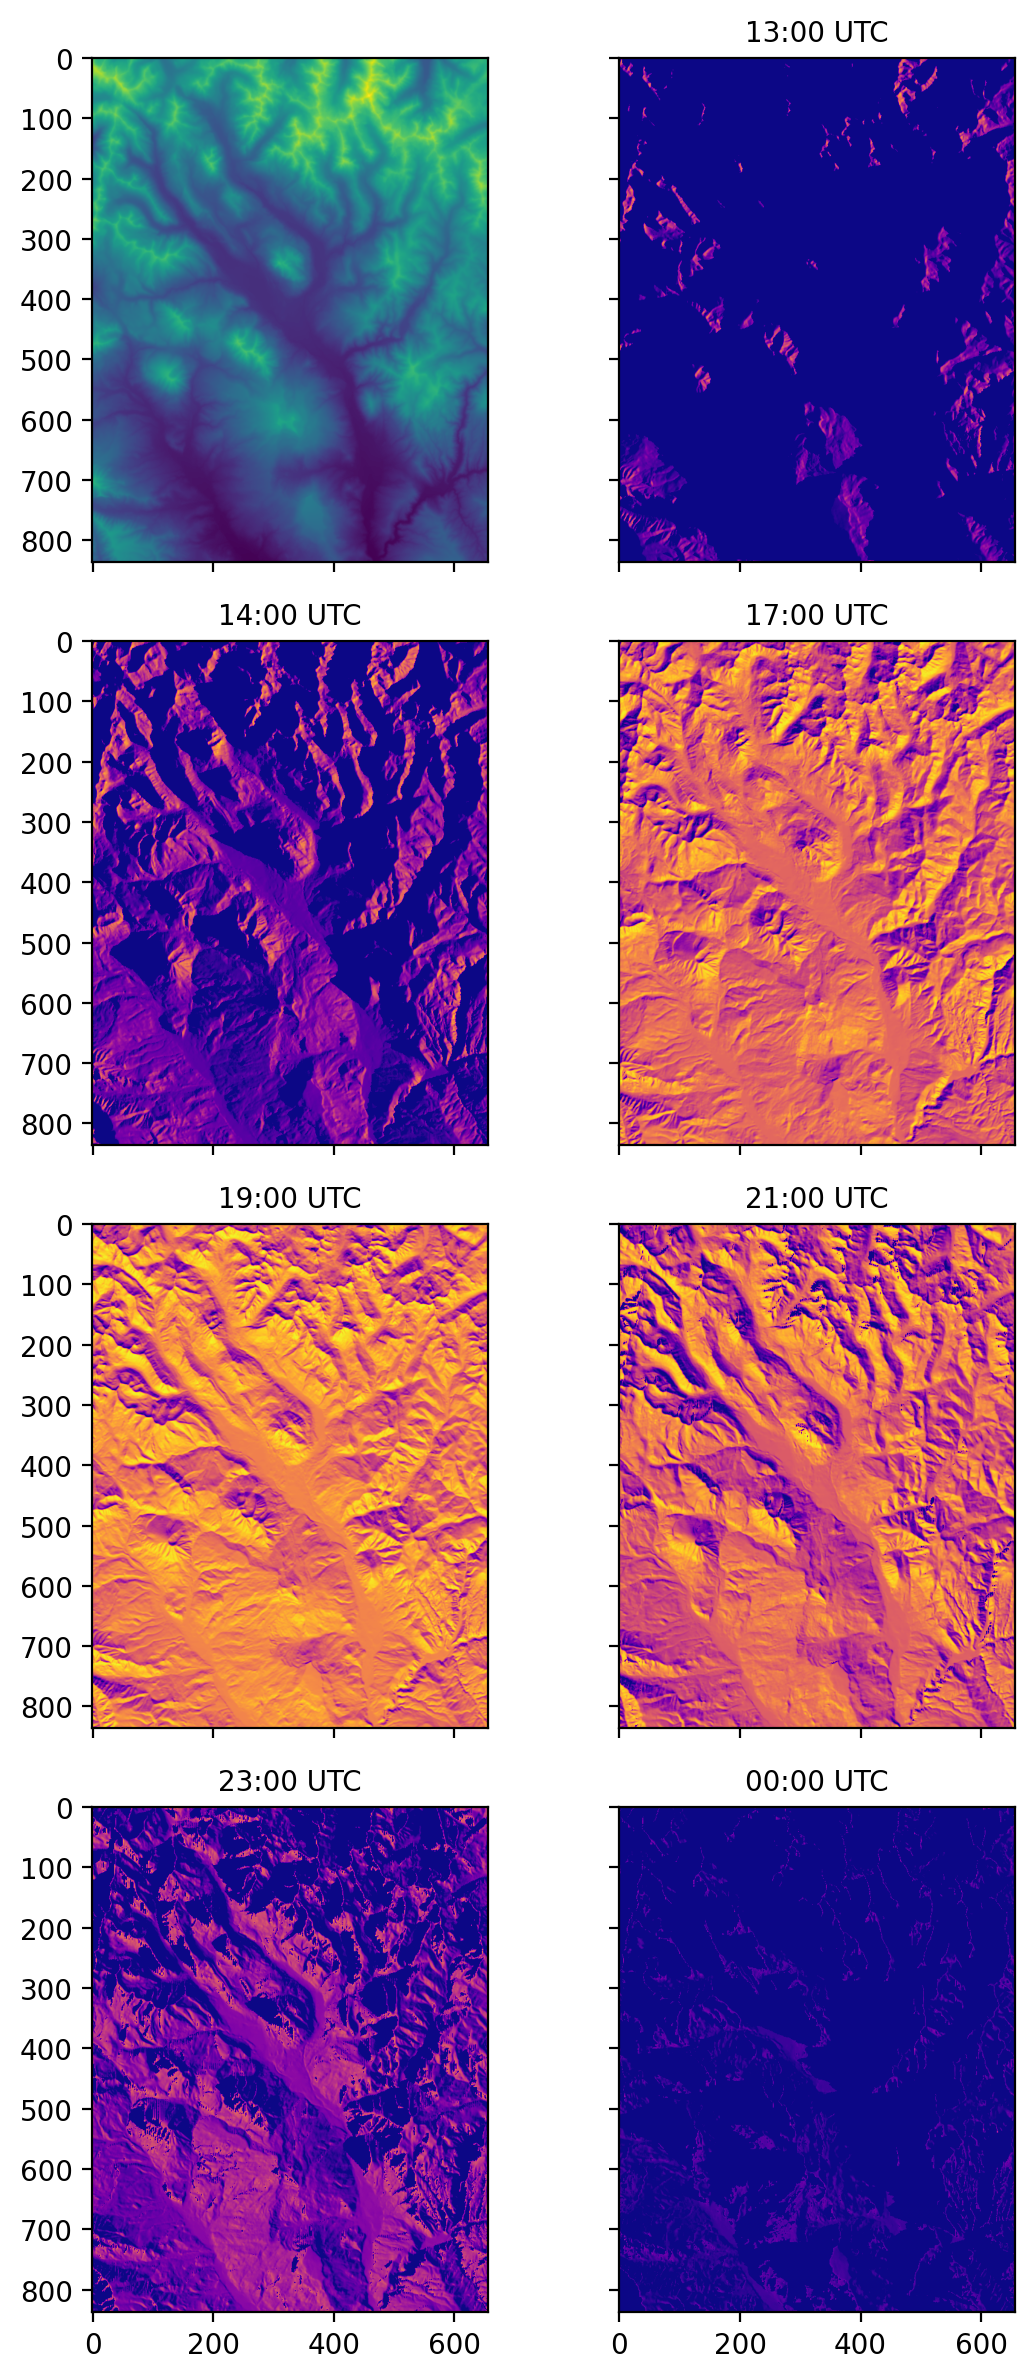

In [18]:
fig, ax = plt.subplots(ncols=2, nrows=4, dpi=200, figsize=(6,12), sharex=True, sharey=True)
ax = ax.flatten()

axes_args=dict(cmap='plasma', vmax=1)
title_args=dict(fontsize=10)

ax[0].imshow(topo_shade.topo.dem)
ax[1].imshow(illumination_angles['2022-03-01 13:00'], **axes_args)
ax[1].set_title('13:00 UTC', **title_args)
ax[2].imshow(illumination_angles['2022-03-01 14:00'], **axes_args)
ax[2].set_title('14:00 UTC', **title_args)
ax[3].imshow(illumination_angles['2022-03-01 17:00'], **axes_args)
ax[3].set_title('17:00 UTC', **title_args)
ax[4].imshow(illumination_angles['2022-03-01 19:00'], **axes_args)
ax[4].set_title('19:00 UTC', **title_args)
ax[5].imshow(illumination_angles['2022-03-01 21:00'], **axes_args)
ax[5].set_title('21:00 UTC', **title_args)
ax[6].imshow(illumination_angles['2022-03-01 23:00'], **axes_args)
ax[6].set_title('23:00 UTC', **title_args)
ax[7].imshow(illumination_angles['2022-03-02 00:00'], **axes_args)
ax[7].set_title('00:00 UTC', **title_args)

plt.tight_layout();

### Check Shadows!

## Read a given HRRR hour shortwave variable

In [19]:
# Set the PROJ_LIB environment variable
# Annoying Jupter bug
import os
os.environ['PROJ_LIB'] = '/uufs/chpc.utah.edu/common/home/skiles-group1/jmeyer/conda/envs/smeshr/share/proj' 

In [20]:
hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + 'hrrr.20220301/hrrr.t09z.wrfsfcf06.grib2', 'cubic')

### Explore the bands

In [21]:
hrrr_dswrf.grib_metadata(hrrr_dswrf.grib_file, 1)

{'GRIB_COMMENT': 'Geopotential height [gpm]',
 'GRIB_DISCIPLINE': '0(Meteorological)',
 'GRIB_ELEMENT': 'HGT',
 'GRIB_FORECAST_SECONDS': '21600',
 'GRIB_IDS': 'CENTER=7(US-NCEP) SUBCENTER=0 MASTER_TABLE=2 LOCAL_TABLE=1 SIGNF_REF_TIME=1(Start_of_Forecast) REF_TIME=2022-03-01T09:00:00Z PROD_STATUS=0(Operational) TYPE=1(Forecast)',
 'GRIB_PDS_PDTN': '0',
 'GRIB_PDS_TEMPLATE_ASSEMBLED_VALUES': '3 5 2 0 83 0 0 1 6 1 0 0 255 0 0',
 'GRIB_PDS_TEMPLATE_NUMBERS': '3 5 2 0 83 0 0 0 1 0 0 0 6 1 0 0 0 0 0 255 0 0 0 0 0',
 'GRIB_REF_TIME': '1646125200',
 'GRIB_SHORT_NAME': '0-SFC',
 'GRIB_UNIT': '[gpm]',
 'GRIB_VALID_TIME': '1646146800'}

### Shortwave is usually band number 10

In [22]:
hrrr_dswrf.grib_metadata(hrrr_dswrf.grib_file, 10)

{'GRIB_COMMENT': 'Downward short-wave radiation flux [W/(m^2)]',
 'GRIB_DISCIPLINE': '0(Meteorological)',
 'GRIB_ELEMENT': 'DSWRF',
 'GRIB_FORECAST_SECONDS': '21600',
 'GRIB_IDS': 'CENTER=7(US-NCEP) SUBCENTER=0 MASTER_TABLE=2 LOCAL_TABLE=1 SIGNF_REF_TIME=1(Start_of_Forecast) REF_TIME=2022-03-01T09:00:00Z PROD_STATUS=0(Operational) TYPE=1(Forecast)',
 'GRIB_PDS_PDTN': '0',
 'GRIB_PDS_TEMPLATE_ASSEMBLED_VALUES': '4 7 2 0 83 0 0 1 6 1 0 0 255 0 0',
 'GRIB_PDS_TEMPLATE_NUMBERS': '4 7 2 0 83 0 0 0 1 0 0 0 6 1 0 0 0 0 0 255 0 0 0 0 0',
 'GRIB_REF_TIME': '1646125200',
 'GRIB_SHORT_NAME': '0-SFC',
 'GRIB_UNIT': '[W/(m^2)]',
 'GRIB_VALID_TIME': '1646146800'}

### Get the forecasted hour of a band

In [23]:
hrrr_dswrf.timestep_for_band(10)

datetime.datetime(2022, 3, 1, 15, 0, tzinfo=datetime.timezone.utc)

In [24]:
str(hrrr_dswrf.timestep_for_band(10))

'2022-03-01 15:00:00+00:00'

### The reprojected and interpolated data as an array

In [25]:
ghi = hrrr_dswrf.grib_file.GetRasterBand(10).ReadAsArray()

In [26]:
ghi

array([[245.07609738, 245.07934768, 245.08218786, ..., 252.39474135,
        252.4110088 , 252.42576086],
       [245.23275596, 245.23684647, 245.24049519, ..., 252.40094586,
        252.41635398, 252.43024458],
       [245.38765946, 245.39257862, 245.39702461, ..., 252.40642105,
        252.42097223, 252.43400396],
       ...,
       [244.26905768, 244.26163451, 244.25459395, ..., 244.5056879 ,
        244.55457638, 244.60544979],
       [244.23922876, 244.23160979, 244.22437641, ..., 244.5155309 ,
        244.56367061, 244.61378219],
       [244.20916456, 244.20134028, 244.19390443, ..., 244.52586203,
        244.57325304, 244.62260226]])

## SPLITTING

In [27]:
# basic assumption: diffuse fraction invisible bands is the same as broadband
k = hrrr_dswrf.grib_file.GetRasterBand(11).ReadAsArray() / hrrr_dswrf.grib_file.GetRasterBand(12).ReadAsArray()
k.mean()

0.21235695773115312

In [28]:
ghi.max()

256.1302027402516

## Topo Models

In [29]:
## FINAL EQUATION
# GHI = dswrf_data
# DNI = ((GHI * (1-k)) / (np.cos(zenith[hour]*m.pi/180))) * illumination_angles[date]
# DIF = (DNI * k) * sky_view_factor
# TOT = DNI + DIF

In [30]:
# dem
sky_view_factor
# zenith

masked_array(
  data=[[0.90764373, 0.90160327, 0.87204783, ..., 0.96763542, 0.97887733,
         0.98330146],
        [0.87995018, 0.86740591, 0.81930077, ..., 0.97601105, 0.98206188,
         0.98354592],
        [0.83752437, 0.8177492 , 0.77636379, ..., 0.97050725, 0.97584268,
         0.97335441],
        ...,
        [0.87855814, 0.89022444, 0.8855338 , ..., 0.95064361, 0.95388958,
         0.93882772],
        [0.90449759, 0.86569677, 0.84933238, ..., 0.95202325, 0.94747276,
         0.92465977],
        [0.890127  , 0.82381173, 0.78123565, ..., 0.9661788 , 0.94509181,
         0.91614504]],
  mask=False,
  fill_value=1e+20)

In [31]:
## DSWRF - base model
# Flat model
ghi # HRRR raw
hour = hrrr_dswrf.timestep_for_band(10)
hour = str(hour.strftime('%Y-%m-%d %H:%M'))
hour

'2022-03-01 15:00'

In [32]:
## DSW1
# No cast shadows - no view factor
dni0 = ((ghi * (1-k)) / (np.cos(zenith[hour]*m.pi/180))) * illumination_angles0[hour]
dif0 = (dni0 * k) 
dsw1 = dni0 + dif0

In [33]:
## DSW2
# No cast shadows
dif = dif0 * sky_view_factor
dsw2 = dni0 + dif

In [34]:
## DSW3
# Complete
dni = ((ghi * (1-k)) / (np.cos(zenith[hour]*m.pi/180))) * illumination_angles[hour]
dsw3 = dni + dif

In [35]:
print(dsw1.mean())
print(dsw2.mean())
print(dsw3.mean())

223.09767104895258
220.91011178582673
220.91011178582673


In [36]:
def toposplitModels4(hrrr_dswrf, zenith, azimuth, illumination, sky_view_factor):
    """
    Topo models for HRRR
        Provides splitting method based on 

    Returns:
        ghi  - global horizontal radiation (flat model
        dsw1 - + illumination angle (inc)
        dsw2 - + inc + skyview (vf)
        dsw3 - + inc + vf + shading (COMPLETE)
        
    """
    # define hour
    hour = hrrr_dswrf.timestep_for_band(10)
    hour = str(hour.strftime('%Y-%m-%d %H:%M'))
    
    # variables
    ghi = hrrr_dswrf.grib_file.GetRasterBand(10).ReadAsArray()
    k = hrrr_dswrf.grib_file.GetRasterBand(11).ReadAsArray() / hrrr_dswrf.grib_file.GetRasterBand(12).ReadAsArray()

    # recalculate illumination
    incidence = shade(
        topo_shade.topo.sin_slope,
        topo_shade.topo.aspect,
        azimuth[hour],
        m.cos(m.radians(zenith[hour]))
    )
    ## Topo models
    # DSW1 - No cast shadows - no view factor
    dni0 = ((ghi * (1-k)) / (np.cos(zenith[hour]*m.pi/180))) * incidence
    dif0 = (dni0 * k) 
    dsw1 = dni0 + dif0
    # DSW2 - No cast shadows
    dif = dif0 * sky_view_factor
    dsw2 = dni0 + dif
    # DSW3 - Final model
    dni = ((ghi * (1-k)) / (np.cos(zenith[hour]*m.pi/180))) * illumination[hour]
    dsw3 = dni + dif

    return ghi, dsw1, dsw2, dsw3
    
    

In [37]:
from topocalc.shade import shade

In [38]:
# zenith00 = np.array(list(zenith.values()))
illum = shade(
    topo_shade.topo.sin_slope,
    topo_shade.topo.aspect,
    azimuth[hour],
    m.cos(m.radians(zenith[hour]))
)

In [39]:
illum

array([[0.        , 0.        , 0.        , ..., 0.24107323, 0.29818026,
        0.33563556],
       [0.        , 0.        , 0.        , ..., 0.24839452, 0.30083037,
        0.33216339],
       [0.        , 0.        , 0.        , ..., 0.26512481, 0.30654921,
        0.32954348],
       ...,
       [0.69220539, 0.60343195, 0.45029404, ..., 0.08612681, 0.1017944 ,
        0.16421657],
       [0.44385424, 0.29180417, 0.13754932, ..., 0.16380705, 0.17759025,
        0.21577649],
       [0.18463124, 0.04746782, 0.00261743, ..., 0.29822936, 0.22704443,
        0.19279207]])

In [40]:
ghi, dsw1, dsw2, dsw3 = toposplitModels4(hrrr_dswrf, zenith, azimuth, illumination_angles, sky_view_factor)


In [41]:
hour0 = hrrr_dswrf.timestep_for_band(10)
hour0.strftime('%Y-%m-%d') 
(hour0 + timedelta(days=1)).strftime('%Y-%m-%d')

'2022-03-02'

In [42]:
if 'topo_shade' not in globals():
# if 'my_variable' in locals():
    print("The variable 'topo_shade' exists in the global scope.")
else:
    print("The variable 'topo_shade' does not exist in the global scope.")

The variable 'topo_shade' does not exist in the global scope.


## Plot

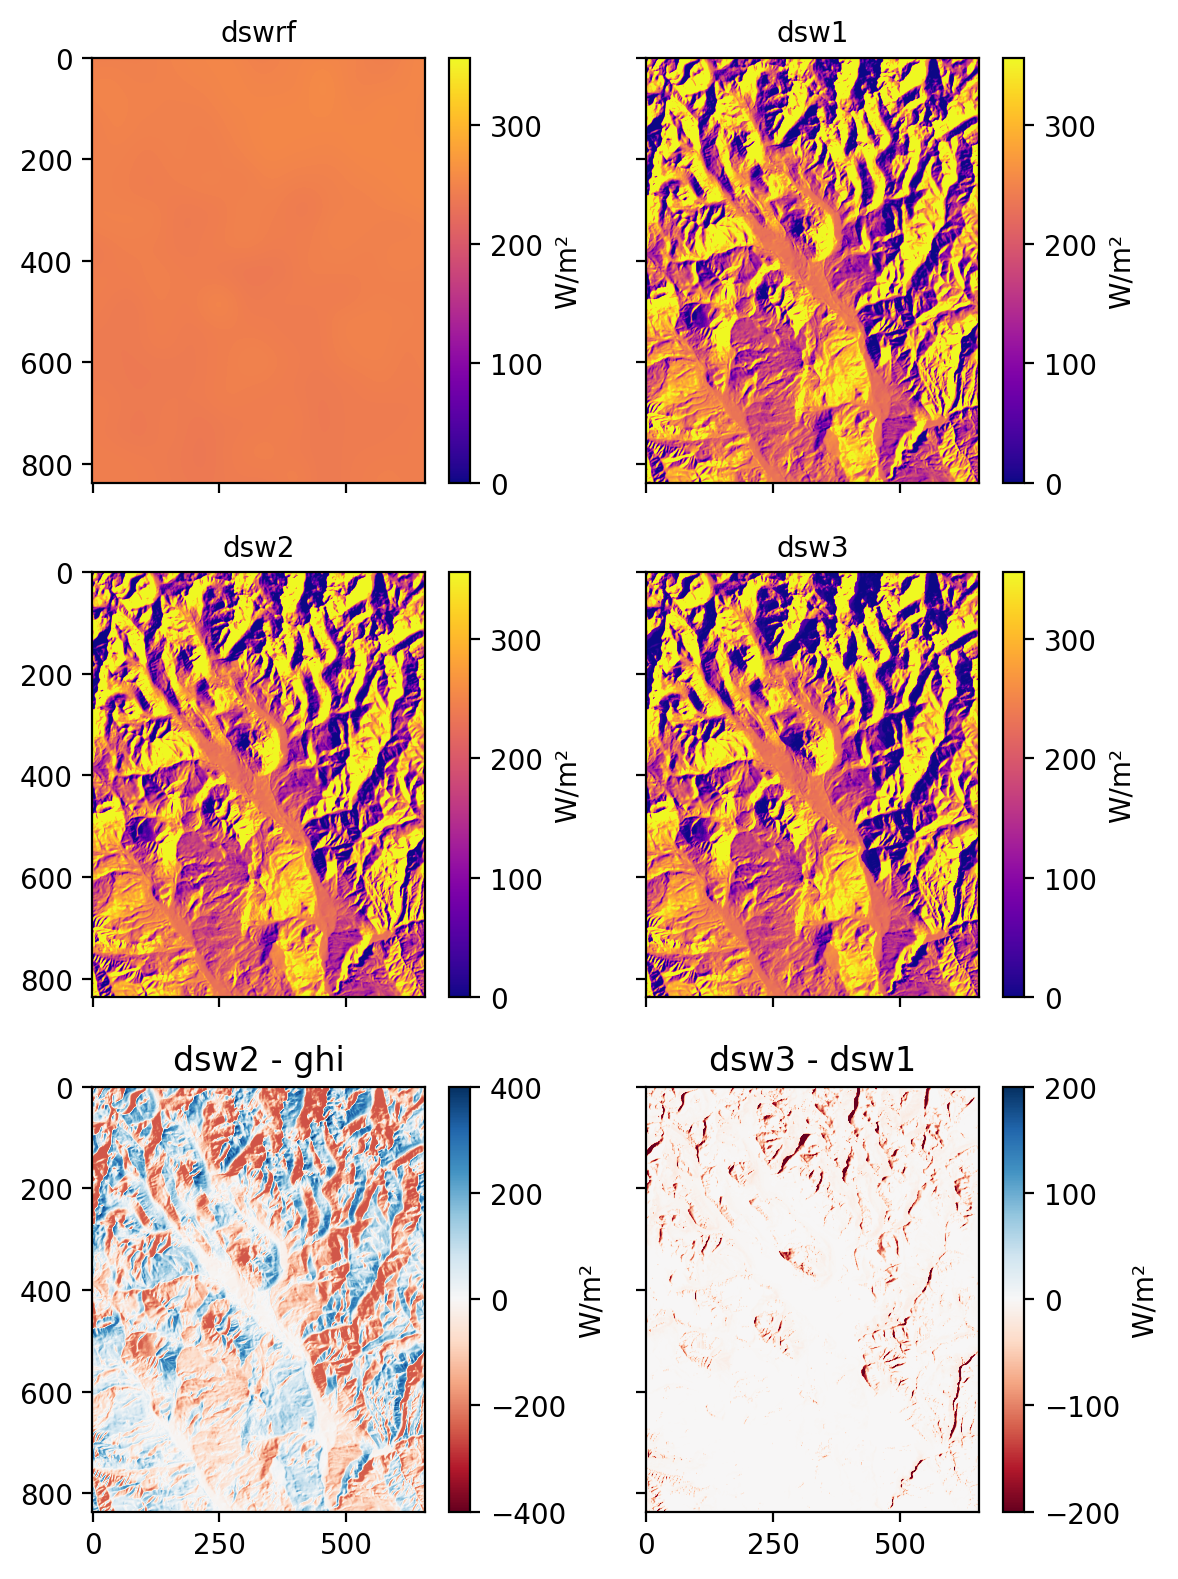

In [43]:
# PLOT MODELS
fig, ax = plt.subplots(ncols=2, nrows=3, dpi=200, figsize=(6,8), sharex=True, sharey=True)
ax = ax.flatten()

axes_args = dict(cmap='plasma', vmax=(ghi.max() + 100), vmin=0)
title_args = dict(fontsize=10)

# Plot and create colorbars
im0 = ax[0].imshow(ghi, **axes_args)
ax[0].set_title('dswrf', **title_args)
fig.colorbar(im0, ax=ax[0], label="W/m²")

im1 = ax[1].imshow(dsw1, **axes_args)
ax[1].set_title('dsw1', **title_args)
fig.colorbar(im1, ax=ax[1], label="W/m²")

im2 = ax[2].imshow(dsw2, **axes_args)
ax[2].set_title('dsw2', **title_args)
fig.colorbar(im2, ax=ax[2], label="W/m²")

im3 = ax[3].imshow(dsw3, **axes_args)
ax[3].set_title('dsw3', **title_args)
fig.colorbar(im3, ax=ax[3], label="W/m²")

im4 = ax[4].imshow(dsw2 - ghi, cmap='RdBu', vmin=-400, vmax=400)
ax[4].set_title('dsw2 - ghi')
fig.colorbar(im4, ax=ax[4], label="W/m²")

im5 = ax[5].imshow(dsw3 - dsw1, cmap='RdBu', vmin=-200, vmax=200)
ax[5].set_title('dsw3 - dsw1')
fig.colorbar(im5, ax=ax[5], label="W/m²")

plt.tight_layout()
plt.show()


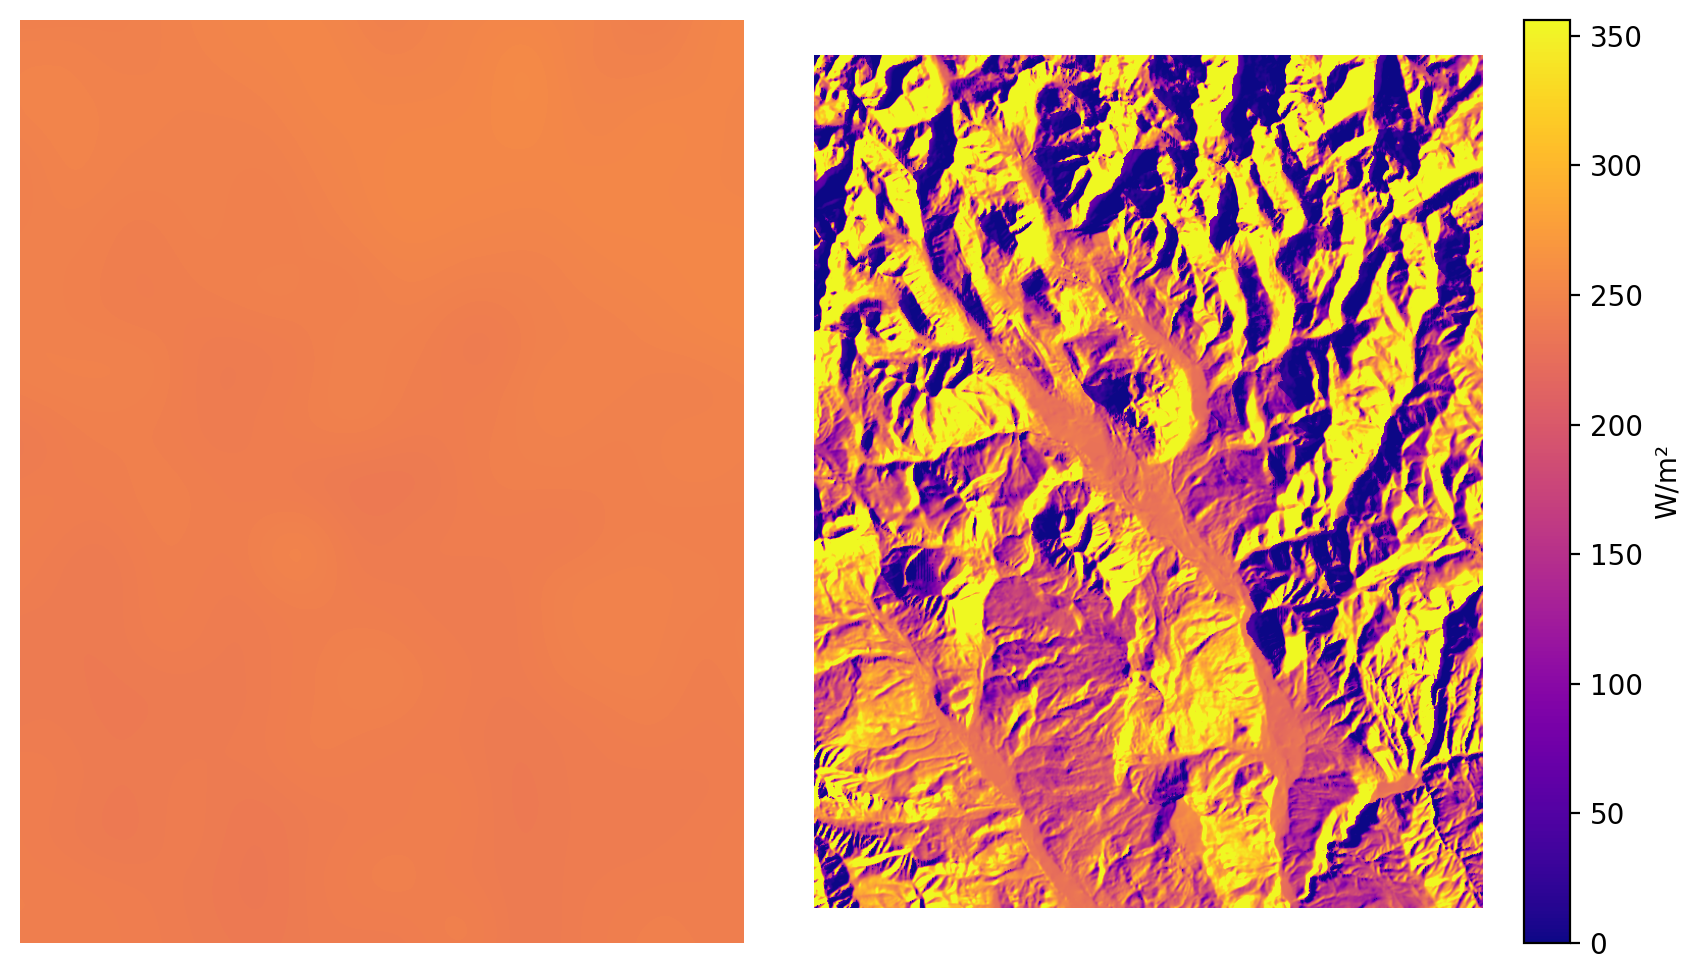

In [57]:
fig, ax = plt.subplots(ncols=2, nrows=1, dpi=200, figsize=(9,5), sharex=True, sharey=True)
ax = ax.flatten()

plt.axis('off')

axes_args = dict(cmap='plasma', vmax=(ghi.max() + 100), vmin=0)
title_args = dict(fontsize=10)

im2 = ax[0].imshow(ghi, **axes_args)
ax[0].set_title('', **title_args)
ax[0].axis('off')
# fig.colorbar(im2, ax=ax[0], label="W/m²")

im3 = ax[1].imshow(dsw3, **axes_args)
ax[1].set_title('', **title_args)
fig.colorbar(im3, ax=ax[1], label="W/m²")

plt.tight_layout()
plt.show()

In [44]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# function for topo models
def topo_models(date):
    hour = str(hrrr_dswrf.timestep_for_band(10))
    ghi = hrrr_dswrf.grib_file.GetRasterBand(10).ReadAsArray()
    print(date)

In [ ]:
# Read and warp HRRR file for same day
time_utc = 18 # 15 is 9AM?
if(time_utc-6 < 10):
    time_utcf = "0"+str(time_utc-6)
else:
    time_utcf = time_utc - 6 # adjust for forecast hour

print(f"utc hour {time_utc} or f6 {time_utcf}")
topo_nc_path=ERW_TOPO_FILE
hrrr_file = f"{HRRR_DATA}hrrr.20220301/hrrr.t{time_utcf}z.wrfsfcf06.grib2"
hrrr_warp = swo.hrrr_warp_domain(hrrr_file, topo_nc_path, resample_option="cubic")